# Understanding the PLGA Microparticle Release Dataset

**File:** `mp_dataset_processed.xlsx` · 4,913 rows × 13 columns · **321 formulations**

This notebook is a *guided visual tour* of the dataset. Every figure is preceded by a short note
saying **what it shows** and **what to look for**, so that by the end you understand the shape of the
data before any modelling.

### What is this dataset?
Each **formulation** is a batch of PLGA (poly-lactic-*co*-glycolic acid) polymer microparticles loaded
with a drug. Over time the drug is released as the polymer degrades. The dataset records, for each
formulation, a **drug-release curve**: the cumulative fraction of drug released measured at several
time points.

The table is in **long format** — one row per *(formulation, time point)*:

| Group | Columns | Varies within a formulation? |
|---|---|---|
| **Identity** | `Formulation Index` | — (the group key) |
| **Drug descriptors** | `Drug MW`, `Drug TPSA`, `Drug LogP` | No — constant per formulation |
| **Polymer** | `Polymer MW` (kDa), `LA/GA` (lactic:glycolic ratio) | No |
| **Formulation** | `Initial Drug-to-Polymer Ratio`, `Particle Size` (µm), `Drug Loading Capacity` (%), `Drug Encapsulation Efficiency` (%), `Solubility Enhancer Concentration` | No |
| **Time series** | `Time` (days), `Release` (cumulative fraction, 0–1) | **Yes** — these two define the curve |

So the 10 static features + drug repeat down every row of a formulation; only `Time` and `Release`
move. Understanding that structure is the key to reading every figure below correctly:
**static features are analysed one-row-per-formulation, the release curve is analysed row-by-row.**

## 0 · Setup & load

We load the processed workbook and — if the original source file is present — attach the human-readable
**drug name** and **formulation method** (these are dropped from the numeric processed file but make the
labels far more informative). Everything still works if that file is missing.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# ---- Consistent, colour-blind-safe style -------------------------------------
# Categorical hues: Okabe-Ito palette (safe for all common colour-vision types).
OKABE = ['#0072B2', '#E69F00', '#009E73', '#D55E00',
         '#CC79A7', '#56B4E9', '#F0E442', '#000000']
SEQ, DIVERGING = 'viridis', 'RdBu_r'   # magnitude / polarity ramps
INK, MUTED, GRID = '#222222', '#666666', '#dddddd'

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 110,
    'font.size': 11, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.edgecolor': MUTED, 'axes.labelcolor': INK, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'axes.spines.top': False, 'axes.spines.right': False,
    'figure.autolayout': False,
})

# ---- Load --------------------------------------------------------------------
df = pd.read_excel("mp_dataset_processed.xlsx")

# Optional enrichment: drug name + formulation method from the source workbook.
try:
    meta = (pd.read_excel("mp_dataset_initial.xlsx", sheet_name="PLGA_MPs")
              .rename(columns={"Drug Encapuslation Efficiency": "Drug Encapsulation Efficiency"})
              [["Formulation Index", "Drug", "Formulation Method"]]
              .drop_duplicates("Formulation Index"))
    df = df.merge(meta, on="Formulation Index", how="left")
    HAVE_META = df["Drug"].notna().any()
except Exception as e:
    HAVE_META = False
    print("Metadata not attached (source file missing) — proceeding numeric-only:", e)

print(f"{df.shape[0]:,} rows × {df.shape[1]} columns · "
      f"{df['Formulation Index'].nunique()} formulations · metadata attached: {HAVE_META}")
df.head(4)

4,913 rows × 15 columns · 321 formulations · metadata attached: True


,Formulation Index,Drug MW,Drug TPSA,Drug LogP,Polymer MW,LA/GA,Initial Drug-to-Polymer Ratio,Particle Size,Drug Loading Capacity,Drug Encapsulation Efficiency,Solubility Enhancer Concentration,Time,Release,Drug,Formulation Method
0,1,639.83,116.04,5.7289,75.0,3.0,0.666667,47.723,35.41,88.3,0.5,0.000000,0.000000,moxidectin,O/W
1,1,639.83,116.04,5.7289,75.0,3.0,0.666667,47.723,35.41,88.3,0.5,1.889764,0.062622,moxidectin,O/W
2,1,639.83,116.04,5.7289,75.0,3.0,0.666667,47.723,35.41,88.3,0.5,7.181102,0.056751,moxidectin,O/W
3,1,639.83,116.04,5.7289,75.0,3.0,0.666667,47.723,35.41,88.3,0.5,13.984252,0.058708,moxidectin,O/W


### Two derived tables we reuse everywhere

- **`form`** — one row per formulation (the static features). Analysing distributions on `df` directly
  would *overweight* formulations that happen to have more time points, so we always use `form`.
- **`summary`** — one row per formulation summarising its release **curve** into a few numbers:
  duration, number of points, final/max release, **AUC** (area under the normalised-time curve — a
  compact "fast vs slow release" score), **early release** at 24/48/72 h (= days 1/2/3), and
  **t½** (time to reach 50 % release).

In [ ]:
STATIC = ['Drug MW', 'Drug TPSA', 'Drug LogP', 'Polymer MW', 'LA/GA',
          'Initial Drug-to-Polymer Ratio', 'Particle Size', 'Drug Loading Capacity',
          'Drug Encapsulation Efficiency', 'Solubility Enhancer Concentration']

# One row per formulation
form = df.drop_duplicates('Formulation Index').set_index('Formulation Index')

def t_half(t, r, level=0.5):
    # First time the curve crosses `level` (linear interp); NaN if never reached.
    above = np.where(r >= level)[0]
    if len(above) == 0:
        return np.nan
    i = above[0]
    if i == 0:
        return t[0]
    r0, r1, t0, t1 = r[i-1], r[i], t[i-1], t[i]
    return t0 if r1 == r0 else t0 + (level - r0) * (t1 - t0) / (r1 - r0)

rows = []
for fid, sub in df.groupby('Formulation Index'):
    sub = sub.sort_values('Time')
    # collapse any duplicate time points so interpolation x is strictly increasing
    g = sub.groupby('Time', as_index=False)['Release'].mean()
    t, r = g['Time'].to_numpy(), g['Release'].to_numpy()
    tmax = t.max()
    tn = t / tmax if tmax > 0 else t                      # normalised time 0..1
    rows.append(dict(
        n_points=len(t), duration=tmax,
        r_final=r[-1], r_max=r.max(),
        auc_norm=np.trapz(r, tn) if tmax > 0 else np.nan, # 0=slow, 1=instant
        rel_24h=np.interp(1.0, t, r), rel_48h=np.interp(2.0, t, r),
        rel_72h=np.interp(3.0, t, r),
        t_half=t_half(t, r),
    ))
summary = pd.DataFrame(rows, index=df.groupby('Formulation Index').groups.keys())
summary.index.name = 'Formulation Index'
summary = summary.join(form[STATIC])
if HAVE_META:
    summary = summary.join(form[['Drug', 'Formulation Method']])
summary.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
n_points,321.0,15.29,7.16,5.00,11.00,13.00,18.00,48.00
duration,321.0,30.02,25.47,3.00,15.21,28.03,33.30,237.73
r_final,321.0,0.90,0.11,0.61,0.83,0.93,0.99,1.08
r_max,321.0,0.90,0.11,0.61,0.84,0.93,0.99,1.08
auc_norm,321.0,0.61,0.15,0.25,0.49,0.61,0.72,0.99
rel_24h,321.0,0.22,0.20,0.00,0.05,0.16,0.35,0.94
rel_48h,321.0,0.29,0.23,0.00,0.09,0.22,0.47,0.99
rel_72h,321.0,0.34,0.25,0.00,0.13,0.30,0.52,1.01
t_half,321.0,10.21,13.59,0.11,2.54,6.61,14.76,175.79
Drug MW,321.0,432.41,232.60,130.08,312.45,392.47,477.51,1488.81


## 1 · How the data is shaped

**What it shows.** Left: how many time points each formulation's curve has. Right: how long each
release experiment ran (its total duration, on a log scale).

**What to look for.** The curves are **short and unevenly sampled** — a typical formulation has ~13
measured points (some as few as 5). Durations span an enormous range, from a few days to ~238 days —
this is why we normalise time when comparing curves. Both facts shape every later choice.

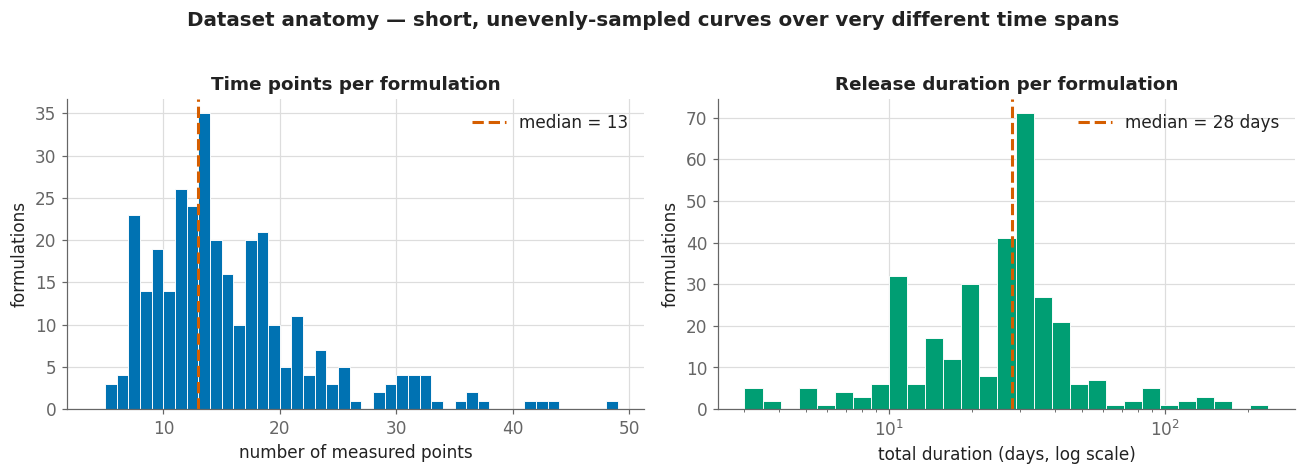

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

ax[0].hist(summary['n_points'], bins=range(4, summary['n_points'].max()+2),
           color=OKABE[0], edgecolor='white', linewidth=0.6)
ax[0].axvline(summary['n_points'].median(), color=OKABE[3], lw=2, ls='--',
              label=f"median = {summary['n_points'].median():.0f}")
ax[0].set(title='Time points per formulation', xlabel='number of measured points',
          ylabel='formulations')
ax[0].legend(frameon=False)

ax[1].hist(summary['duration'], bins=np.logspace(np.log10(summary['duration'].min()),
           np.log10(summary['duration'].max()), 30), color=OKABE[2], edgecolor='white', linewidth=0.6)
ax[1].set_xscale('log')
ax[1].axvline(summary['duration'].median(), color=OKABE[3], lw=2, ls='--',
              label=f"median = {summary['duration'].median():.0f} days")
ax[1].set(title='Release duration per formulation', xlabel='total duration (days, log scale)',
          ylabel='formulations')
ax[1].legend(frameon=False)
fig.suptitle('Dataset anatomy — short, unevenly-sampled curves over very different time spans',
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout(); plt.show()

## 2 · The target we care about — release curves

**What it shows.** Every one of the 321 release curves, drawn faintly. Left uses **real time** (log
scale, because durations vary 100×); right uses **normalised time** (each curve stretched to 0–1 of its
own duration), which makes the *shapes* comparable. The thick line on the right is the median curve.

**What to look for.** This is the whole modelling problem in one picture: some drugs dump their payload
almost immediately ("burst release", curves that shoot up early) while others release slowly and
steadily. The wide vertical spread at every time means the formulation features *must* carry the
information that separates fast from slow — that is exactly what the later sections probe.

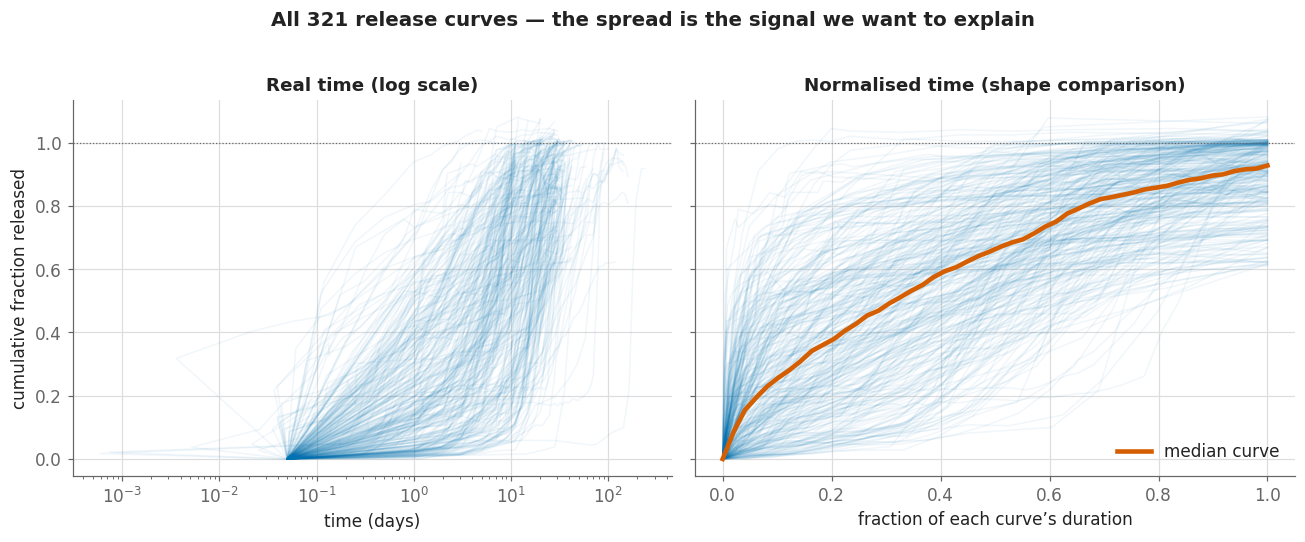

In [4]:
GRIDN = 50
xs = np.linspace(0, 1, GRIDN)
norm_stack = []
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)

for fid, sub in df.groupby('Formulation Index'):
    sub = sub.sort_values('Time')
    g = sub.groupby('Time', as_index=False)['Release'].mean()
    t, r = g['Time'].to_numpy(), g['Release'].to_numpy()
    ax[0].plot(np.where(t == 0, 0.05, t), r, color=OKABE[0], alpha=0.06, lw=1)
    tmax = t.max()
    if tmax > 0:
        norm_stack.append(np.interp(xs, t / tmax, r))
        ax[1].plot(t / tmax, r, color=OKABE[0], alpha=0.06, lw=1)

med = np.median(np.vstack(norm_stack), axis=0)
ax[1].plot(xs, med, color=OKABE[3], lw=3, label='median curve')
ax[0].set_xscale('log')
ax[0].set(title='Real time (log scale)', xlabel='time (days)', ylabel='cumulative fraction released')
ax[1].set(title='Normalised time (shape comparison)', xlabel='fraction of each curve’s duration')
ax[1].legend(frameon=False, loc='lower right')
for a in ax:
    a.axhline(1.0, color=MUTED, lw=0.8, ls=':')
fig.suptitle('All 321 release curves — the spread is the signal we want to explain',
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout(); plt.show()

### 2b · Fast, medium and slow archetypes

**What it shows.** The same curves, but we pick out a handful of representative formulations — the
fastest, median, and slowest releasers by AUC — and draw them boldly with their real measured points.

**What to look for.** Concrete examples of the extremes. Fast releasers reach near-complete release
in a fraction of their span; slow ones climb gradually. The markers remind you how *few* points each
curve actually has.

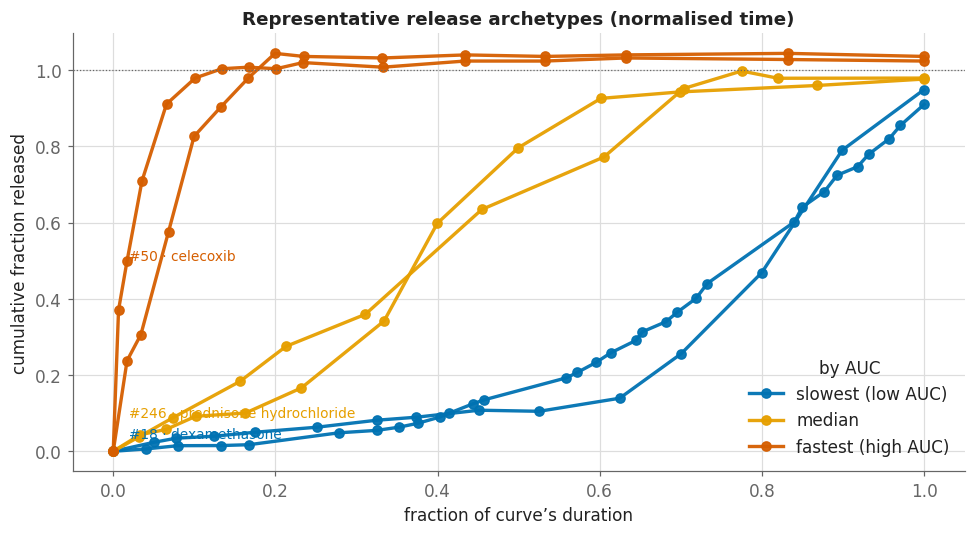

In [5]:
ranked = summary.sort_values('auc_norm')
picks = {
    'slowest (low AUC)':  ranked.index[[0, 1]],
    'median':             ranked.index[[len(ranked)//2 - 1, len(ranked)//2]],
    'fastest (high AUC)': ranked.index[[-1, -2]],
}
colors = {'slowest (low AUC)': OKABE[0], 'median': OKABE[1], 'fastest (high AUC)': OKABE[3]}

fig, ax = plt.subplots(figsize=(9, 5))
for label, fids in picks.items():
    for j, fid in enumerate(fids):
        sub = df[df['Formulation Index'] == fid].sort_values('Time')
        t = sub['Time'].to_numpy(); tmax = t.max()
        name = f" · {sub['Drug'].iloc[0]}" if HAVE_META and pd.notna(sub['Drug'].iloc[0]) else ""
        ax.plot(t / tmax, sub['Release'], '-o', color=colors[label], lw=2.2, ms=6,
                alpha=0.95, label=(label if j == 0 else None))
        if j == 0:
            ax.annotate(f"#{fid}{name}", (0.02, sub['Release'].to_numpy()[min(2, len(sub)-1)]),
                        color=colors[label], fontsize=9)
ax.axhline(1.0, color=MUTED, lw=0.8, ls=':')
ax.set(title='Representative release archetypes (normalised time)',
       xlabel='fraction of curve’s duration', ylabel='cumulative fraction released')
ax.legend(frameon=False, title='by AUC'); fig.tight_layout(); plt.show()

## 3 · Quirks of the release measurements

**What it shows.** Three honest checks on the raw `Release` values. (a) the distribution of every
measured value; (b) the *final* release each formulation reaches; (c) how many curves are **not
perfectly monotonic** (release should only go up, but measurement noise sometimes makes it dip).

**What to look for.** A small number of values sit **above 1.0** (108 rows — shaded red), and some
curves wobble downward. These are real properties of the source data, not errors to hide — the
processed dataset deliberately keeps them. Knowing they exist tells you why a model target might be
clipped or smoothed later.

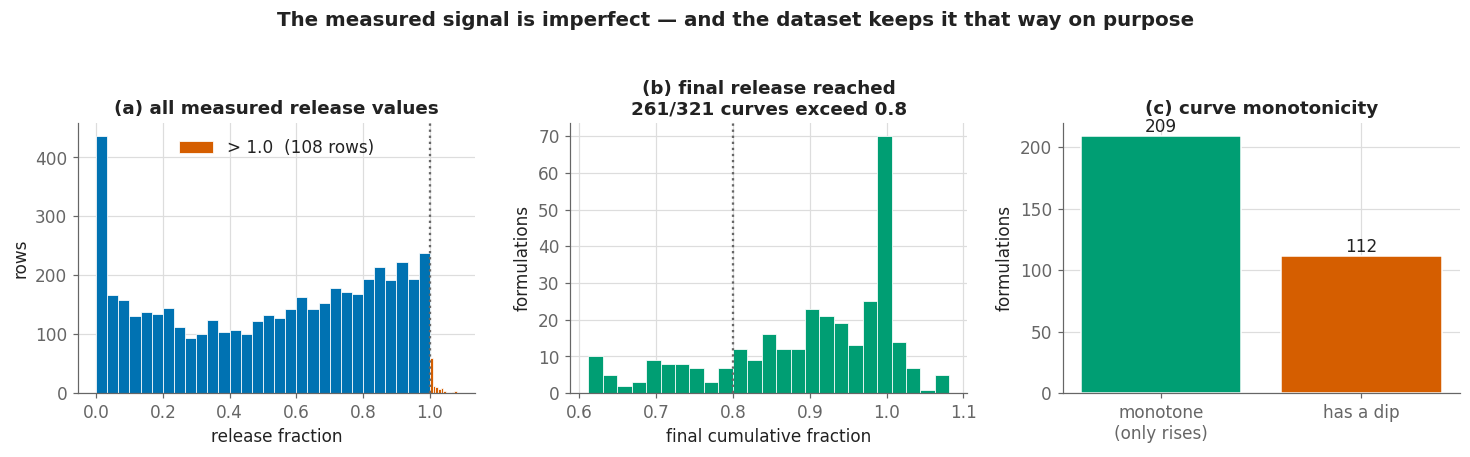

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 4))

vals = df['Release']
ax[0].hist(vals[vals <= 1], bins=30, color=OKABE[0], edgecolor='white', linewidth=0.5)
over = vals[vals > 1]
ax[0].hist(over, bins=10, color=OKABE[3], edgecolor='white', linewidth=0.5,
           label=f'> 1.0  ({len(over)} rows)')
ax[0].axvline(1.0, color=MUTED, ls=':')
ax[0].set(title='(a) all measured release values', xlabel='release fraction', ylabel='rows')
ax[0].legend(frameon=False)

ax[1].hist(summary['r_final'], bins=25, color=OKABE[2], edgecolor='white', linewidth=0.5)
ax[1].axvline(0.8, color=MUTED, ls=':')
n80 = (summary['r_max'] > 0.8).sum()
ax[1].set(title=f'(b) final release reached\n{n80}/{len(summary)} curves exceed 0.8',
          xlabel='final cumulative fraction', ylabel='formulations')

# monotonicity: fraction of curves with any downward step
mono_flags = []
for fid, sub in df.groupby('Formulation Index'):
    r = sub.sort_values('Time')['Release'].to_numpy()
    mono_flags.append(bool(np.any(np.diff(r) < -1e-9)))
n_nonmono = int(np.sum(mono_flags))
ax[2].bar(['monotone\n(only rises)', 'has a dip'],
          [len(mono_flags) - n_nonmono, n_nonmono],
          color=[OKABE[2], OKABE[3]], edgecolor='white')
ax[2].set(title='(c) curve monotonicity', ylabel='formulations')
for i, v in enumerate([len(mono_flags) - n_nonmono, n_nonmono]):
    ax[2].text(i, v, str(v), ha='center', va='bottom')
fig.suptitle('The measured signal is imperfect — and the dataset keeps it that way on purpose',
             fontsize=13, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()

## 4 · What the formulations are made of (static features)

**What it shows.** The distribution of each of the 10 static inputs, computed **once per formulation**.
Skewed quantities (molecular weight, particle size, drug-to-polymer ratio) are drawn on a log x-axis so
the shape is readable.

**What to look for.** These are the "knobs" a formulator sets. Notice how uneven they are: most
particles are small but a few are huge; `Solubility Enhancer Concentration` is zero for most
formulations; `LA/GA` takes only a handful of discrete values. Heavy skew and spikes-at-zero are exactly
the features that benefit from log-scaling or special encoding downstream.

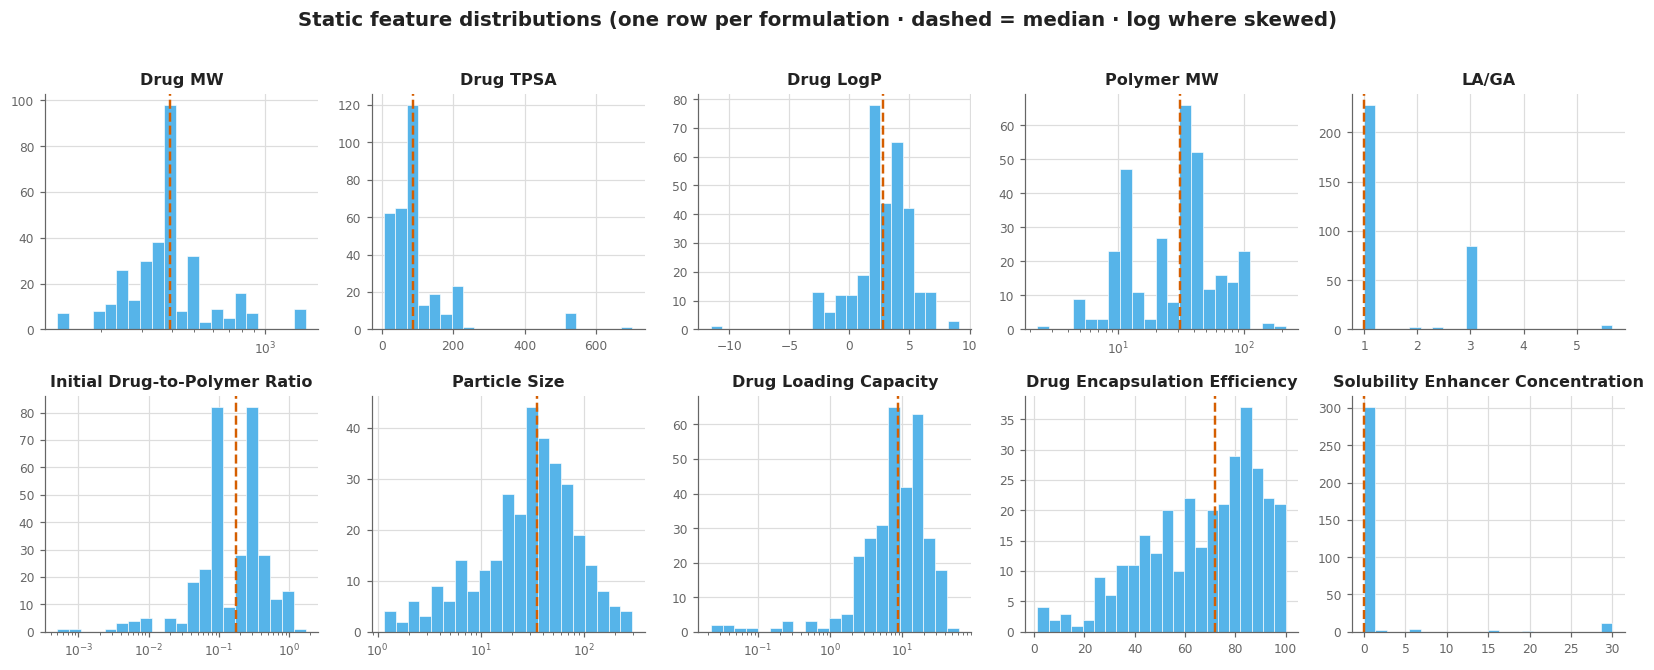

In [7]:
LOGX = {'Drug MW', 'Particle Size', 'Initial Drug-to-Polymer Ratio', 'Drug Loading Capacity', 'Polymer MW'}
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, col in zip(axes.ravel(), STATIC):
    x = form[col].dropna()
    if col in LOGX and (x > 0).all():
        bins = np.logspace(np.log10(x.min()), np.log10(x.max()), 22)
        ax.hist(x, bins=bins, color=OKABE[5], edgecolor='white', linewidth=0.4)
        ax.set_xscale('log')
    else:
        ax.hist(x, bins=22, color=OKABE[5], edgecolor='white', linewidth=0.4)
    ax.axvline(x.median(), color=OKABE[3], lw=1.6, ls='--')
    ax.set_title(col, fontsize=10.5)
    ax.tick_params(labelsize=8)
fig.suptitle('Static feature distributions (one row per formulation · dashed = median · log where skewed)',
             fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout(); plt.show()

## 5 · How the features relate to each other and to release

**What it shows.** A correlation heatmap (Spearman, which captures monotonic relationships without
assuming straight lines) over the 10 static features **plus** the curve summaries — AUC, early release,
and t½. Red = positive correlation, blue = negative.

**What to look for.** Two things. (1) Blocks of correlated *inputs* (e.g. drug-loading vs
encapsulation-efficiency) — these carry overlapping information. (2) The **AUC / early-release / t½
columns** at the edge: any feature that lights up there is a candidate driver of *how fast* a
formulation releases, which is what a model would exploit.

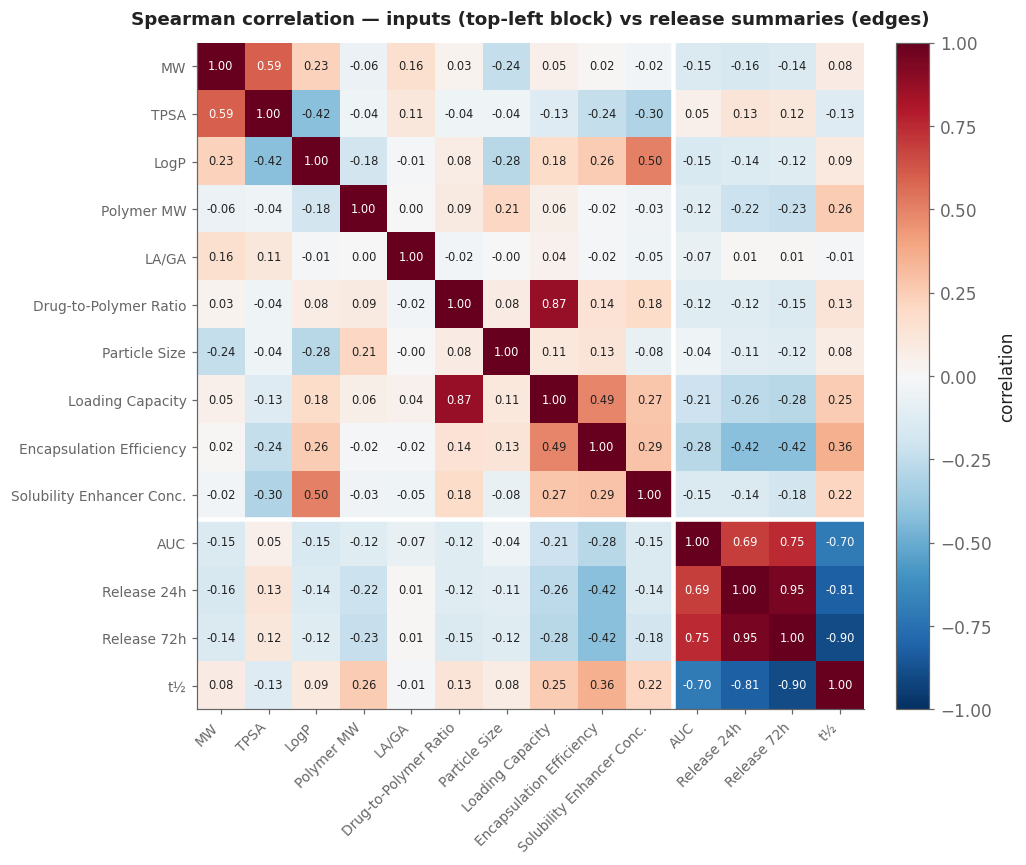

In [8]:
cols = STATIC + ['auc_norm', 'rel_24h', 'rel_72h', 't_half']
corr = summary[cols].corr(method='spearman')
labels = [c.replace('Drug ', '').replace('Concentration', 'Conc.')
           .replace('Initial ', '').replace('auc_norm', 'AUC')
           .replace('rel_24h', 'Release 24h').replace('rel_72h', 'Release 72h')
           .replace('t_half', 't½') for c in cols]

fig, ax = plt.subplots(figsize=(9.5, 8))
im = ax.imshow(corr, cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(cols))); ax.set_yticklabels(labels, fontsize=9)
for i in range(len(cols)):
    for j in range(len(cols)):
        v = corr.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7.5,
                color='white' if abs(v) > 0.55 else INK)
ax.axhline(9.5, color='white', lw=3); ax.axvline(9.5, color='white', lw=3)  # divide inputs / targets
ax.set_title('Spearman correlation — inputs (top-left block) vs release summaries (edges)', pad=12)
cbar = fig.colorbar(im, fraction=0.046, pad=0.04); cbar.set_label('correlation')
ax.grid(False); fig.tight_layout(); plt.show()

## 6 · Which knobs move the release speed?

**What it shows.** Six scatter plots: a candidate driver on the x-axis vs **AUC** (release speed) on the
y-axis, one point per formulation. Colour encodes drug lipophilicity (`Drug LogP`) so you can see a
third dimension. A dashed trend line (LOWESS-style rolling median) summarises each cloud.

**What to look for.** Direction and tightness. A clear downward or upward drift means that knob
genuinely shifts release speed; a shapeless blob means it doesn't (on its own). This is the visual
version of "feature importance" before any model is fit.

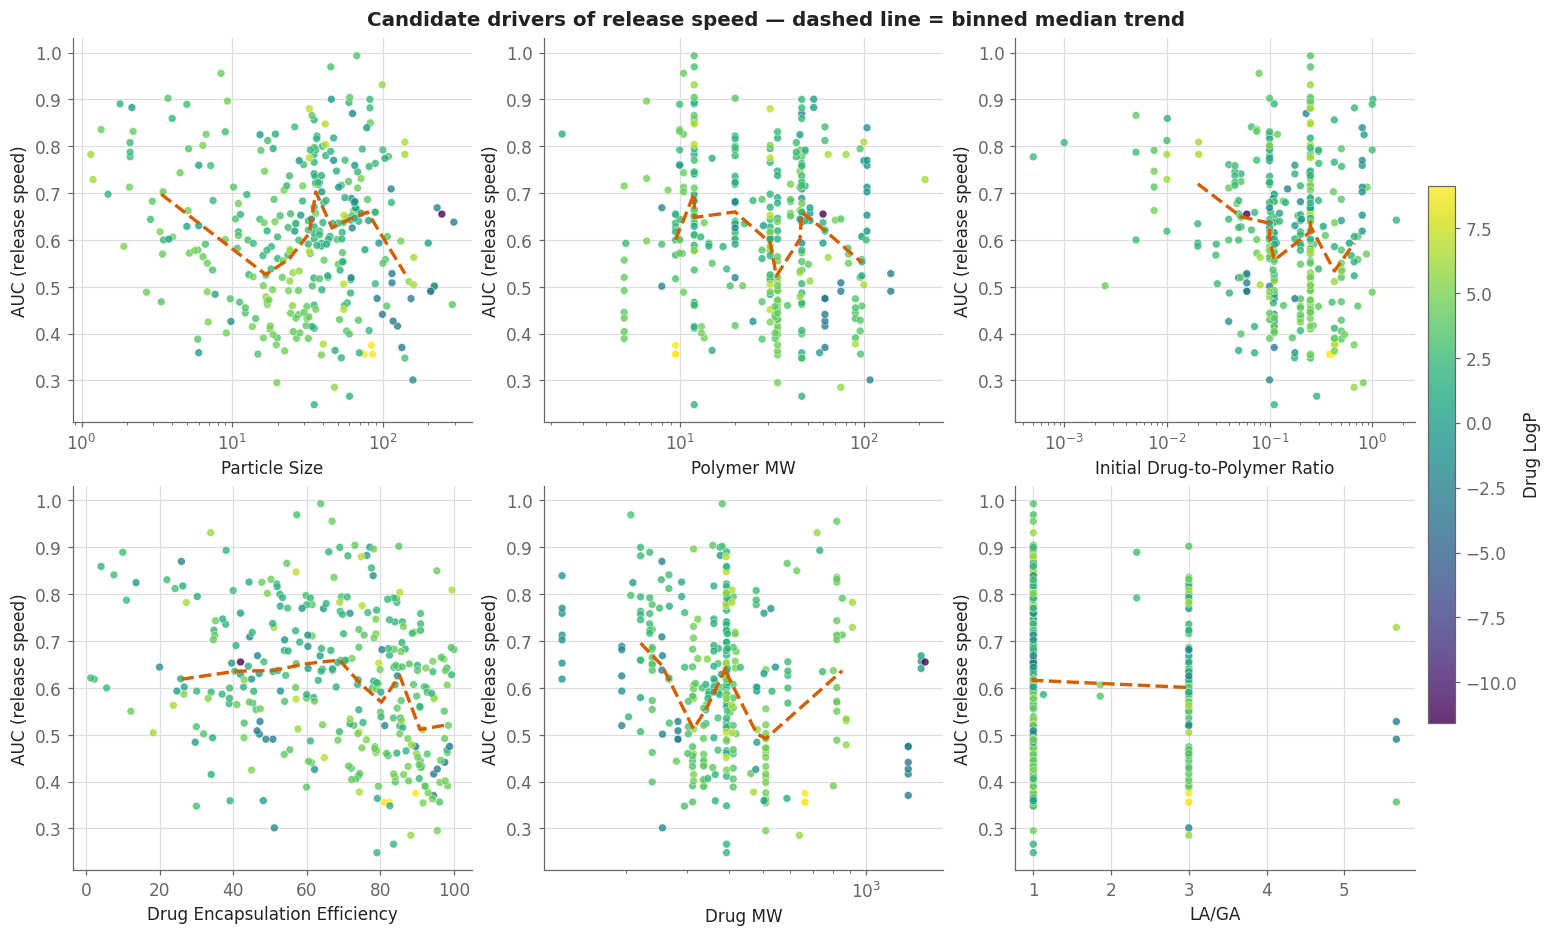

In [9]:
def rolling_median(x, y, bins=10):
    order = np.argsort(x); x, y = np.asarray(x)[order], np.asarray(y)[order]
    edges = np.quantile(x, np.linspace(0, 1, bins + 1))
    cx, cy = [], []
    for a, b in zip(edges[:-1], edges[1:]):
        m = (x >= a) & (x <= b)
        if m.sum() >= 3:
            cx.append(np.median(x[m])); cy.append(np.median(y[m]))
    return cx, cy

drivers = ['Particle Size', 'Polymer MW', 'Initial Drug-to-Polymer Ratio',
           'Drug Encapsulation Efficiency', 'Drug MW', 'LA/GA']
LOG = {'Particle Size', 'Polymer MW', 'Initial Drug-to-Polymer Ratio', 'Drug MW'}
fig, axes = plt.subplots(2, 3, figsize=(14, 8.4), constrained_layout=True)
for ax, col in zip(axes.ravel(), drivers):
    d = summary[[col, 'auc_norm', 'Drug LogP']].dropna()
    sc = ax.scatter(d[col], d['auc_norm'], c=d['Drug LogP'], cmap=SEQ,
                    s=26, alpha=0.8, edgecolor='white', linewidth=0.3)
    cx, cy = rolling_median(d[col].to_numpy(), d['auc_norm'].to_numpy())
    ax.plot(cx, cy, color=OKABE[3], lw=2.2, ls='--')
    if col in LOG:
        ax.set_xscale('log')
    ax.set(xlabel=col, ylabel='AUC (release speed)')   # xlabel names the panel; no redundant title
cbar = fig.colorbar(sc, ax=axes, fraction=0.02, pad=0.01); cbar.set_label('Drug LogP')
fig.suptitle('Candidate drivers of release speed — dashed line = binned median trend',
             fontsize=13, fontweight='bold')
plt.show()

## 7 · Discrete drivers: polymer chemistry & manufacturing method

**What it shows.** Two low-cardinality variables treated as categories. Left: release-speed (AUC)
distribution for each **LA/GA** ratio — the lactic:glycolic makeup of the polymer, which controls how
fast it degrades. Right: AUC by **formulation method** (the emulsion technique), if the source labels
are available.

**What to look for.** Whether whole groups sit higher or lower. If a given LA/GA ratio or method
consistently releases faster/slower, that is a categorical signal a model should encode — and a hint
about the underlying physical chemistry.

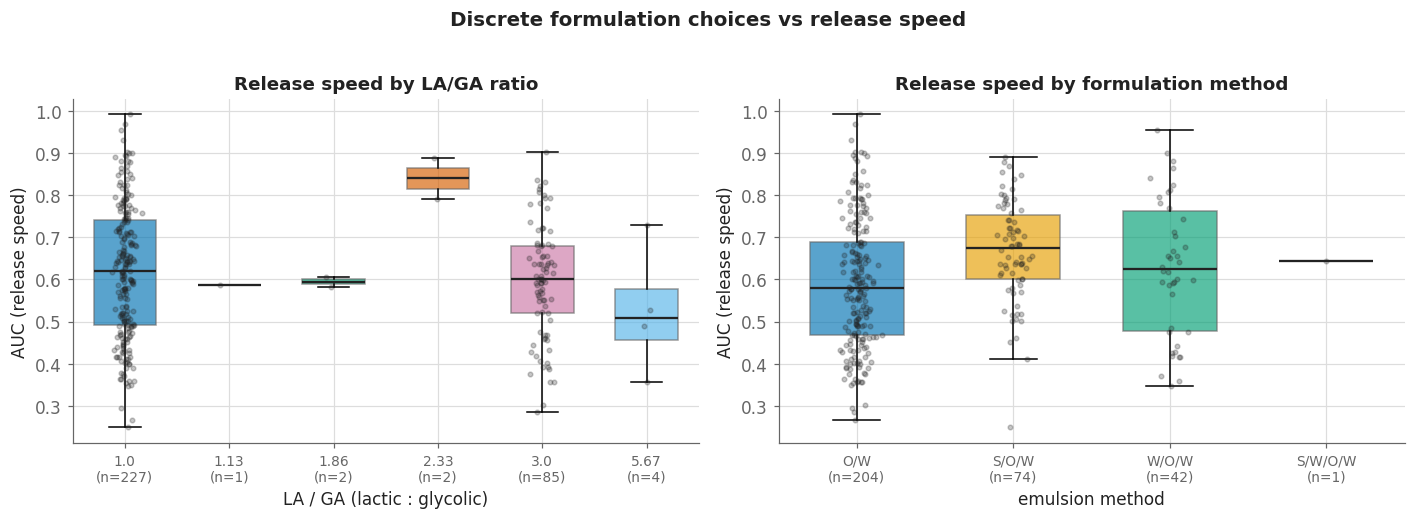

In [10]:
have_method = HAVE_META and 'Formulation Method' in summary
fig, ax = plt.subplots(1, 2 if have_method else 1, figsize=(13 if have_method else 7, 4.6),
                       squeeze=False)
ax = ax[0]

def grouped_box(axis, keys, groups, title, xlabel):
    parts = axis.boxplot([g for g in groups], positions=range(len(groups)),
                         widths=0.6, patch_artist=True, showfliers=False,
                         medianprops=dict(color=INK, lw=1.5))
    for i, box in enumerate(parts['boxes']):
        box.set(facecolor=OKABE[i % len(OKABE)], alpha=0.65, edgecolor=MUTED)
    for i, g in enumerate(groups):
        axis.scatter(np.random.normal(i, 0.05, len(g)), g, s=9, color=INK, alpha=0.25, zorder=3)
    axis.set_xticks(range(len(keys)))
    axis.set_xticklabels([f'{k}\n(n={len(g)})' for k, g in zip(keys, groups)], fontsize=9)
    axis.set(title=title, xlabel=xlabel, ylabel='AUC (release speed)')

lg = summary.dropna(subset=['auc_norm']).groupby('LA/GA')['auc_norm']
keys = sorted(lg.groups); groups = [lg.get_group(k).to_numpy() for k in keys]
grouped_box(ax[0], keys, groups, 'Release speed by LA/GA ratio', 'LA / GA (lactic : glycolic)')

if have_method:
    fm = summary.dropna(subset=['auc_norm', 'Formulation Method']).groupby('Formulation Method')['auc_norm']
    mkeys = sorted(fm.groups, key=lambda k: -fm.get_group(k).size)
    mgroups = [fm.get_group(k).to_numpy() for k in mkeys]
    grouped_box(ax[1], mkeys, mgroups, 'Release speed by formulation method', 'emulsion method')
fig.suptitle('Discrete formulation choices vs release speed', fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout(); plt.show()

## 8 · The drug landscape

**What it shows.** The dataset covers **88 distinct drugs** (defined by their MW/TPSA/LogP fingerprint).
Left: the drugs contributing the most formulations. Right: the chemical space — molecular weight vs
lipophilicity (LogP), with point size ∝ polarity (TPSA).

**What to look for.** The dataset is **imbalanced by drug**: a few drugs dominate (many formulations),
while most appear once or twice. That imbalance is why the modelling pipeline groups by drug when making
cross-validation folds — otherwise the same molecule would leak between train and test. The chemical
space plot shows how broadly (or narrowly) the drugs are spread.

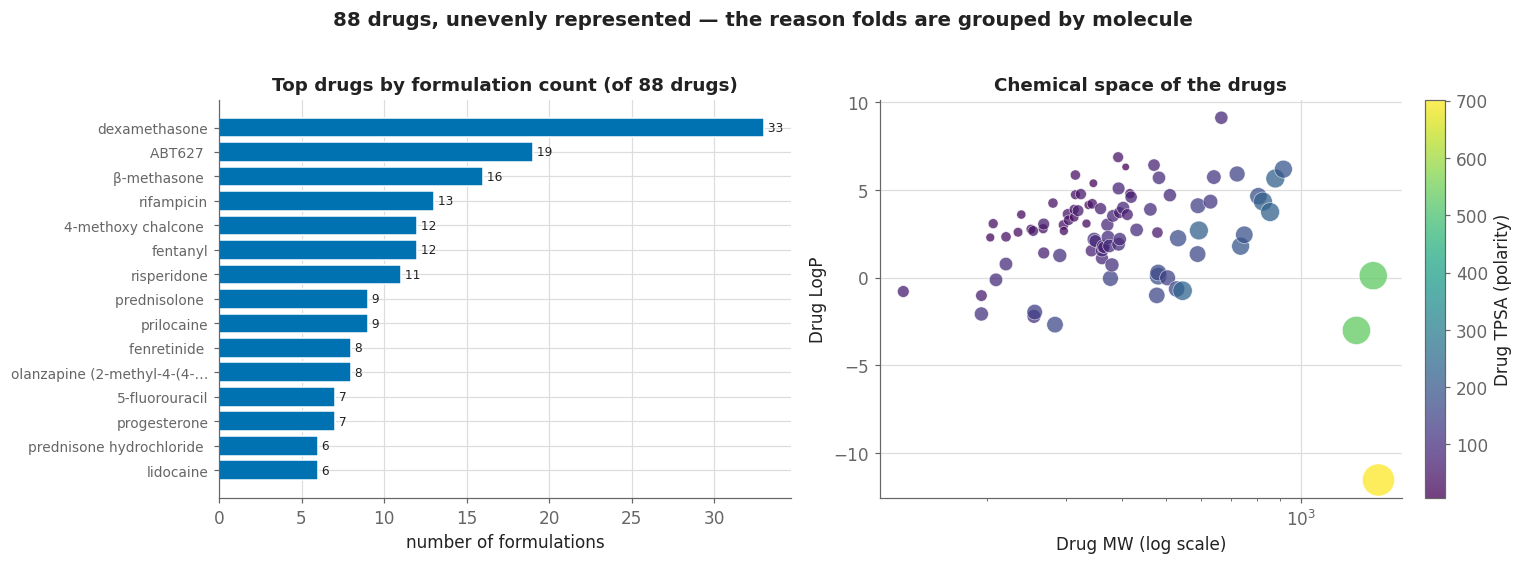

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Left: top drugs by number of formulations
drug_key = list(zip(form['Drug MW'], form['Drug TPSA'], form['Drug LogP']))
n_drugs = pd.Series(drug_key).nunique()
if HAVE_META:
    counts = form['Drug'].value_counts().head(15)[::-1]
    labels = [(str(s)[:26] + '…') if len(str(s)) > 27 else str(s) for s in counts.index]
else:
    counts = pd.Series(drug_key).value_counts().head(15)[::-1]
    labels = [f'MW{int(k[0])}/LogP{k[2]:.1f}' for k in counts.index]
ax[0].barh(range(len(counts)), counts.values, color=OKABE[0], edgecolor='white')
ax[0].set_yticks(range(len(counts))); ax[0].set_yticklabels(labels, fontsize=9)
ax[0].set(title=f'Top drugs by formulation count (of {n_drugs} drugs)',
          xlabel='number of formulations')
for i, v in enumerate(counts.values):
    ax[0].text(v, i, f' {v}', va='center', fontsize=8)

# Right: chemical space (one point per drug)
drug_space = form.groupby(['Drug MW', 'Drug LogP', 'Drug TPSA']).size().reset_index(name='n')
sc = ax[1].scatter(drug_space['Drug MW'], drug_space['Drug LogP'],
                   s=20 + drug_space['Drug TPSA'] * 0.6, c=drug_space['Drug TPSA'],
                   cmap=SEQ, alpha=0.75, edgecolor='white', linewidth=0.4)
ax[1].set_xscale('log')
ax[1].set(title='Chemical space of the drugs', xlabel='Drug MW (log scale)', ylabel='Drug LogP')
cbar = fig.colorbar(sc, ax=ax[1], fraction=0.046, pad=0.04); cbar.set_label('Drug TPSA (polarity)')
fig.suptitle('88 drugs, unevenly represented — the reason folds are grouped by molecule',
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout(); plt.show()

## Key takeaways

1. **Long format, curve target.** 321 formulations, each a short (~13-point) drug-release curve. Static
   features repeat down the rows; only `Time`/`Release` vary. *Analyse statics per-formulation, curves
   per-row.*
2. **Enormous time range (3 → 238 days).** Comparisons must use **normalised time**; raw time needs a
   log axis.
3. **The signal is the spread.** At any time the release fraction varies widely across formulations —
   that variation is what the formulation features are meant to explain.
4. **Imperfect-but-preserved measurements.** 108 values exceed 1.0 and some curves dip; the dataset
   keeps them deliberately, so model targets may need clipping/smoothing.
5. **Skewed, spiky inputs.** MW, particle size and drug-to-polymer ratio are heavy-tailed;
   solubility-enhancer is mostly zero; LA/GA and method are effectively categorical.
6. **Correlated features & real drivers.** Loading vs encapsulation overlap; particle size, polymer MW
   and LA/GA show the clearest links to release speed.
7. **Drug imbalance.** 88 drugs, a few dominating — the reason cross-validation folds are grouped by
   molecule to avoid leakage.

*Next step after understanding the data: the preprocessing/feature phase in `fuzzypharma/` turns this
into the crisp / fuzzy / hybrid feature tables used for modelling.*